# Dermoscopic Lesion Segmentation: Comparing Three Classical Methods

This notebook walks through the full pipeline of the project and compares three
non-learning segmentation methods on dermoscopic images of skin lesions:

1. **Multi-channel Otsu** thresholding, refined by a Chan-Vese active contour
2. **LBP Clustering**, after Pereira et al. (2020)
3. **Statistical Region Merging**, after Celebi et al. (2008)

All the algorithms live in the `dermoseg` package under `src/`. This notebook
only calls them and draws the results, so the code shown here stays readable
and the notebook cannot drift away from what the benchmark script runs.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from dermoseg import visualization as viz
from dermoseg.data import iter_samples, load_sample
from dermoseg.pipeline import METHODS, run_all_methods
from dermoseg.preprocessing import preprocess_with_mask
from dermoseg.segmentation import lbp, otsu, region_merging

plt.rcParams["figure.dpi"] = 90
print("methods:", ", ".join(METHODS))

methods: Otsu, LBP, SRM


## 1. The dataset

Twenty dermoscopic images from the ISIC archive, ten melanomas and ten nevi,
each paired with an expert-drawn segmentation mask used as ground truth.

The pairing is what makes the comparison quantitative: every predicted mask is
scored against the expert's with the Dice coefficient.

20 images
melanoma    10
nevus       10


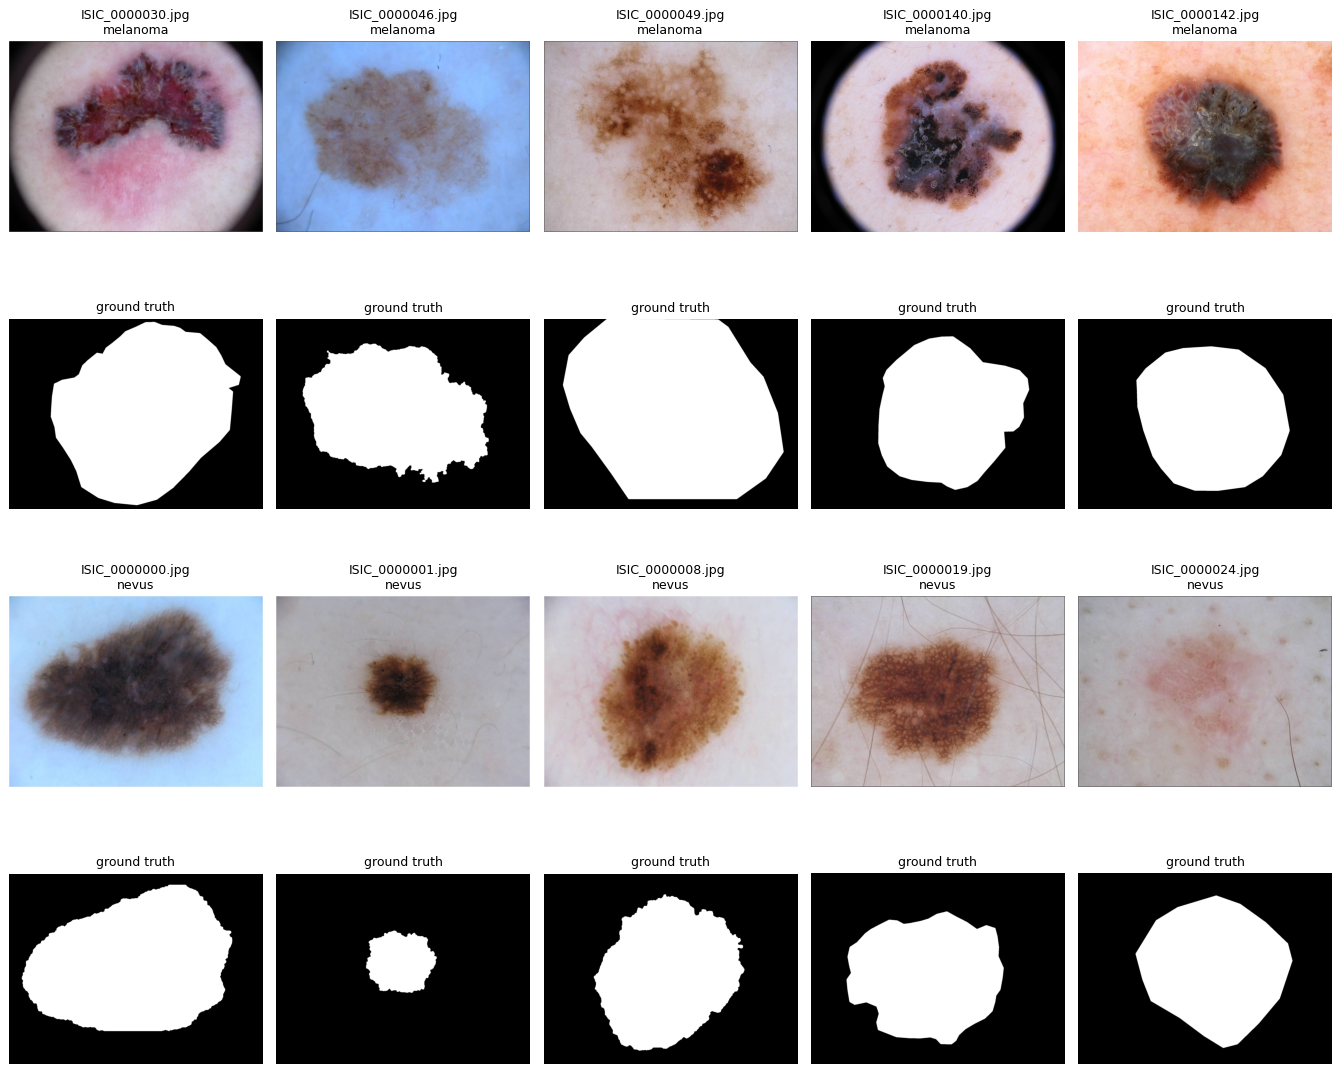

In [2]:
samples = list(iter_samples())
print(f"{len(samples)} images")
print(pd.Series([s.category for s in samples]).value_counts().to_string())

figure = viz.plot_dataset_overview(samples[:5] + samples[10:15])
plt.show()

## 2. Preprocessing

Two artefacts have to go before any segmenter sees the image.

**The dermoscope frame.** The instrument images the skin through a circular
lens, so the corners of many ISIC images are black. No intensity-based method
can tell a black corner from a dark lesion, so the disc is detected and the
outside is whitened and cropped away.

**Hair.** Dark elongated structures crossing the lesion border break both the
thresholds and the region merging. Following DullRazor, hairs are found by
grayscale closing with elongated structuring elements (a closing with an
element wider than a hair erases it, so the difference reveals it), then
inpainted from the surrounding skin.

Images with little hair are left untouched: inpainting a clean image only
blurs the border we are trying to find.

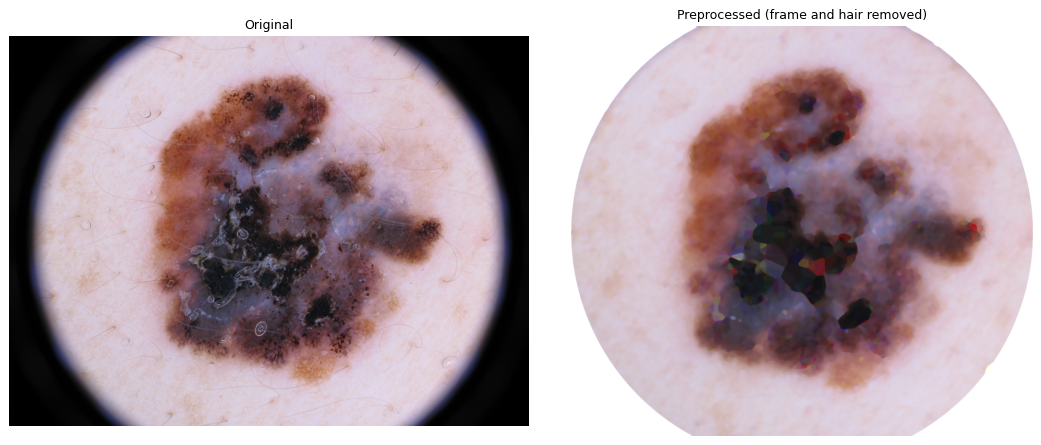

original (2112, 2816, 3) -> preprocessed (2112, 2379, 3)
valid (inside the dermoscope disc): 84.5% of pixels


In [3]:
sample = load_sample(ROOT / "data" / "melanoma" / "ISIC_0000140.jpg")
image, valid_mask = preprocess_with_mask(sample.image)

figure = viz.plot_preprocessing(sample.image, image)
plt.show()

print(f"original {sample.image.shape} -> preprocessed {image.shape}")
print(f"valid (inside the dermoscope disc): {valid_mask.mean():.1%} of pixels")

## 3. Method 1: Multi-channel Otsu

Otsu's threshold is computed independently on R, G and B. A lesion is darker
than skin in all three, but blue carries the strongest melanin contrast, so
the channels are combined as `(R and G) or B`: a pixel is lesion when red
*and* green agree, or when blue alone is confident.

That mask has ragged borders, so it seeds a Chan-Vese active contour which
relaxes onto the real intensity boundary.

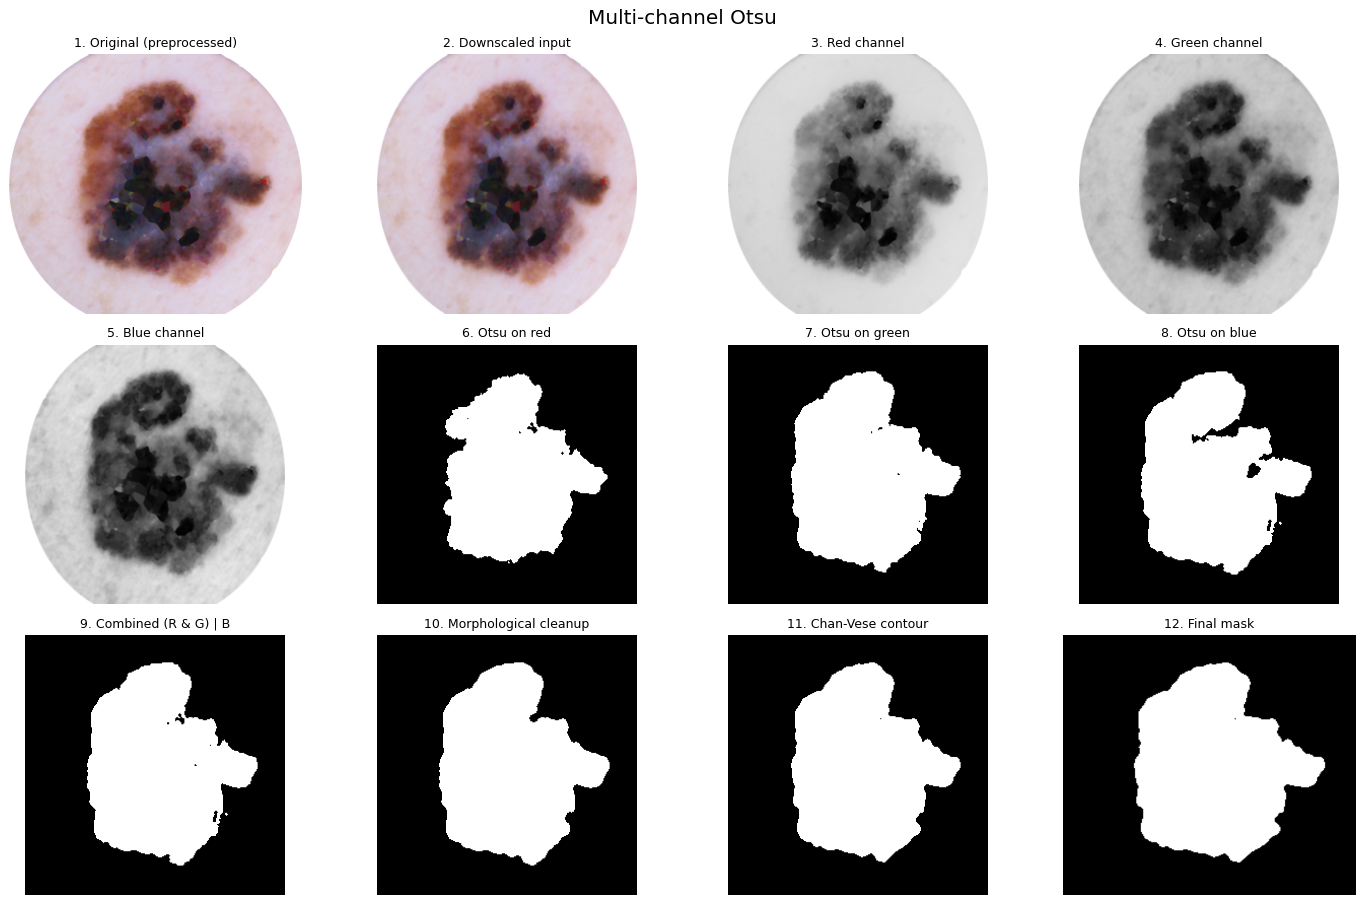

{'red': 0.627, 'green': 0.552, 'blue': 0.577}


In [4]:
result_otsu = otsu.segment(image)
figure = viz.plot_pipeline(result_otsu, title="Multi-channel Otsu", original=image)
plt.show()

print({name: round(value, 3) for name, value in result_otsu.info["thresholds"].items()})

## 4. Method 2: LBP Clustering

The assumption is textural: lesion skin is busier than healthy skin.

Local Binary Patterns with P=8 neighbours at radius R=1 label each pixel by the
sign pattern of its neighbourhood. The flat patterns (code 0, and the eight
powers of two, meaning a single brighter neighbour) mark smooth skin;
everything else marks texture. Binarising on that subset gives a texture map,
which is smoothed into a continuous field L.

L is then stacked with the luminance Y into a synthetic image `[L, Y, L]` and
converted to CIE L\*a\*b\*. Clustering the (a\*, b\*) chromaticity of *that*
image separates lesion from skin, and the **pinkness** score
`max(a*, 0) - min(b*, 0)` picks which of the two clusters is the lesion, with
no training and no labels.

One caveat specific to cropped images: the whitened corners turn pure green in
the pseudo-RGB, an extreme in (a\*, b\*). Left in, they would capture a cluster
outright and k-means would separate disc from corners rather than lesion from
skin, so the fit is restricted to the valid area.

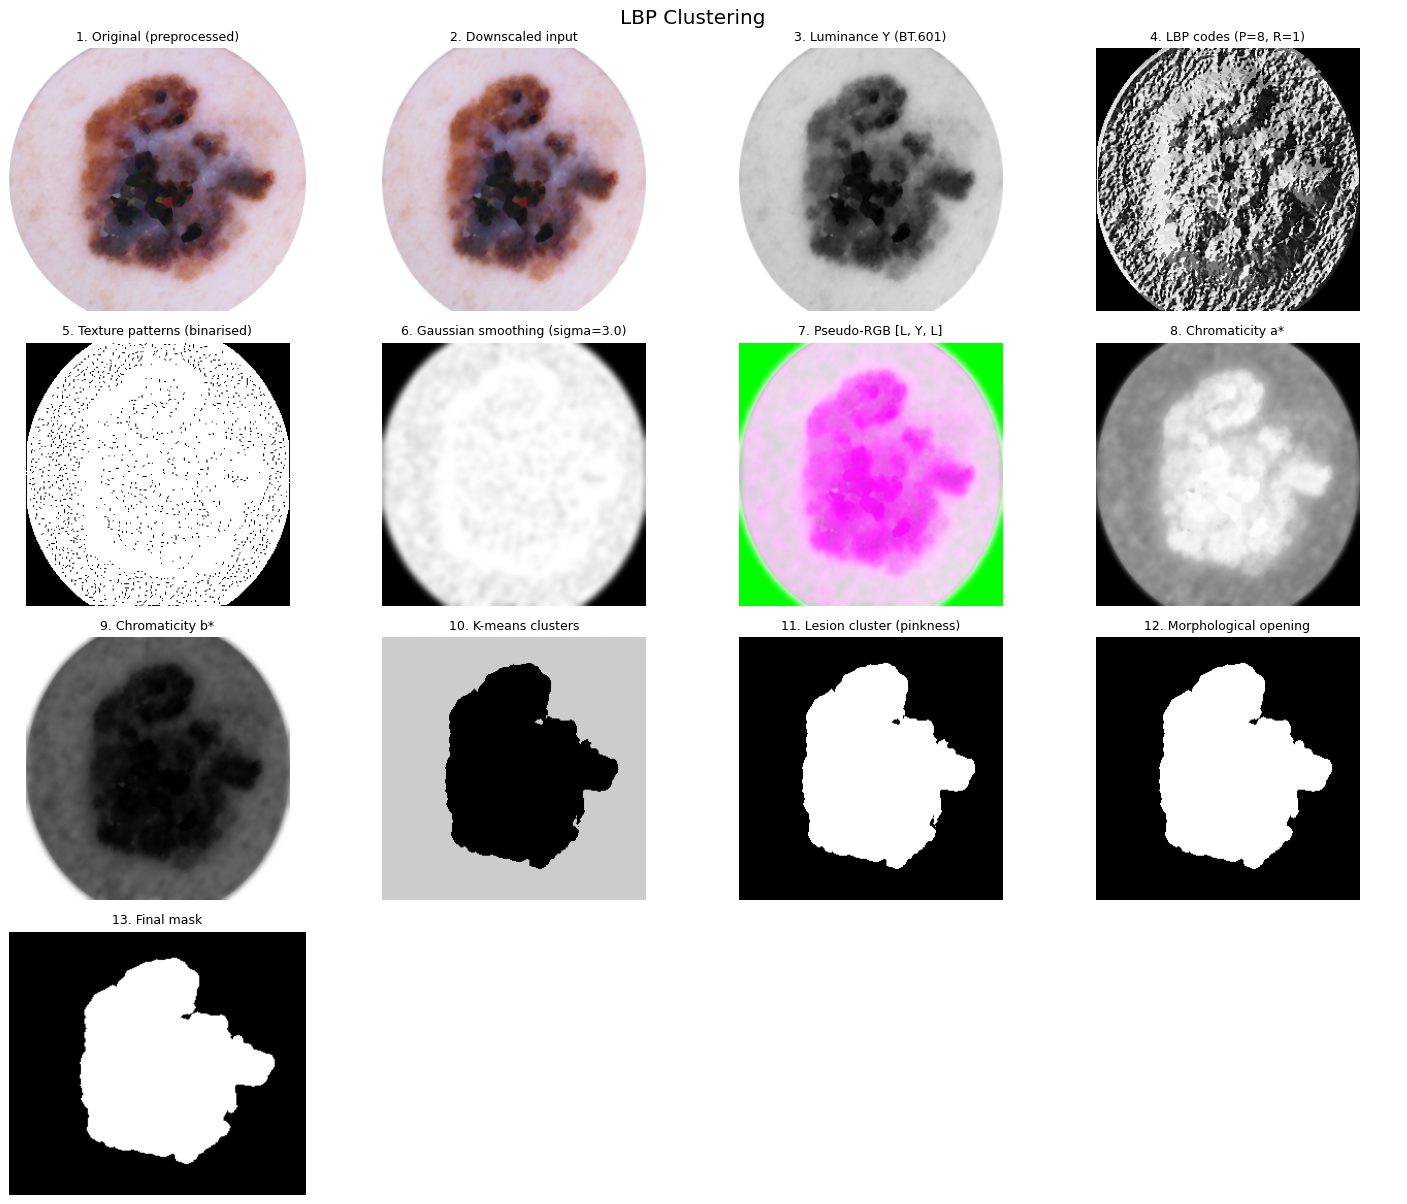

pinkness per cluster: [127.0, 31.1] -> lesion is cluster 0


In [5]:
result_lbp = lbp.segment(image, sigma=3.0, valid_mask=valid_mask)
figure = viz.plot_pipeline(result_lbp, title="LBP Clustering", original=image)
plt.show()

scores = [round(value, 1) for value in result_lbp.info["pinkness_scores"]]
print(f"pinkness per cluster: {scores} -> lesion is cluster {result_lbp.info['lesion_cluster']}")

## 5. Method 3: Statistical Region Merging

SRM visits pairs of neighbouring pixels in order of increasing intensity
difference and merges them through a union-find structure whenever their
region means differ by less than a statistical bound. The bound tightens as
regions grow, so early merges are easy and late merges must be well supported.
The Q parameter sets how permissive it is: smaller Q, fewer and larger regions.

That produces an over-segmentation, not a lesion. Regions are then scored on
three criteria (darkness relative to skin, centrality, and saturation above
skin), and the best region is merged with any close runner-up, because lesions
are routinely split across several regions.

The skin reference comes from a band along the image border, which after
cropping is almost entirely healthy skin. No training required.

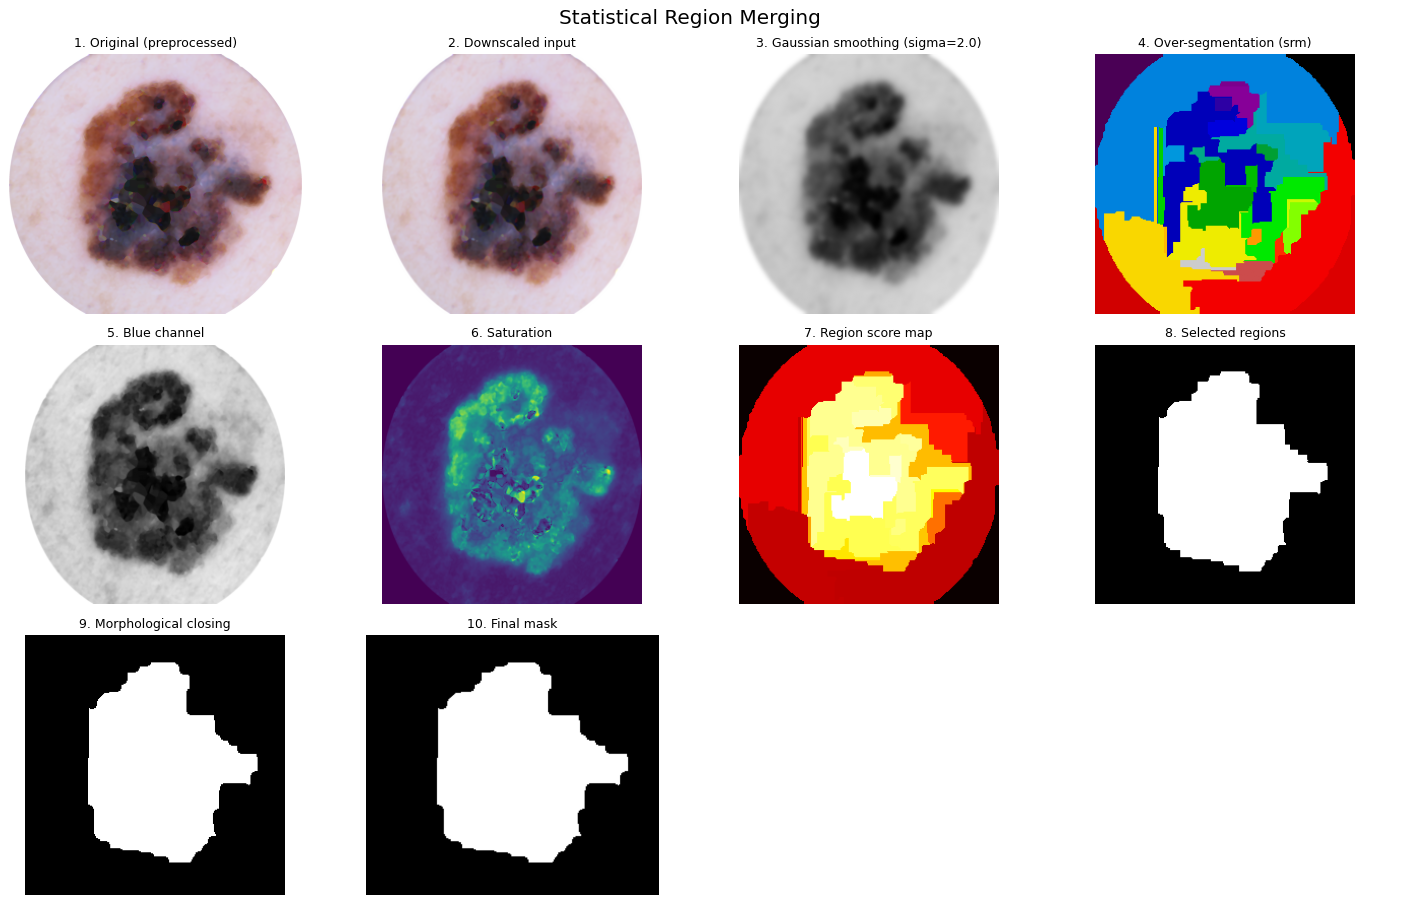

31 regions at Q=25.0


In [6]:
result_srm = region_merging.segment(image, scale=25.0, gaussian_sigma=2.0, backend="srm")
figure = viz.plot_pipeline(result_srm, title="Statistical Region Merging", original=image)
plt.show()

print(f"{result_srm.info['n_regions']} regions at Q={result_srm.info['scale']}")

### Felzenszwalb as a reference point

Felzenszwalb's graph-based segmentation solves a similar over-segmentation
problem much faster. It is a *different* algorithm, so it is reported
separately and never labelled SRM.

In [7]:
result_fz = region_merging.segment(image, scale=25.0, gaussian_sigma=2.0, backend="felzenszwalb")
print(f"SRM          {result_srm.info['n_regions']:3d} regions")
print(f"Felzenszwalb {result_fz.info['n_regions']:3d} regions")

SRM           31 regions
Felzenszwalb  32 regions


## 6. Comparing the three on one image

Each raw mask goes through the same post-processing (hole filling, an
inversion guard, and a convex hull that ignores distant specks of noise), so
the three are compared on equal terms and only the segmentation itself differs.

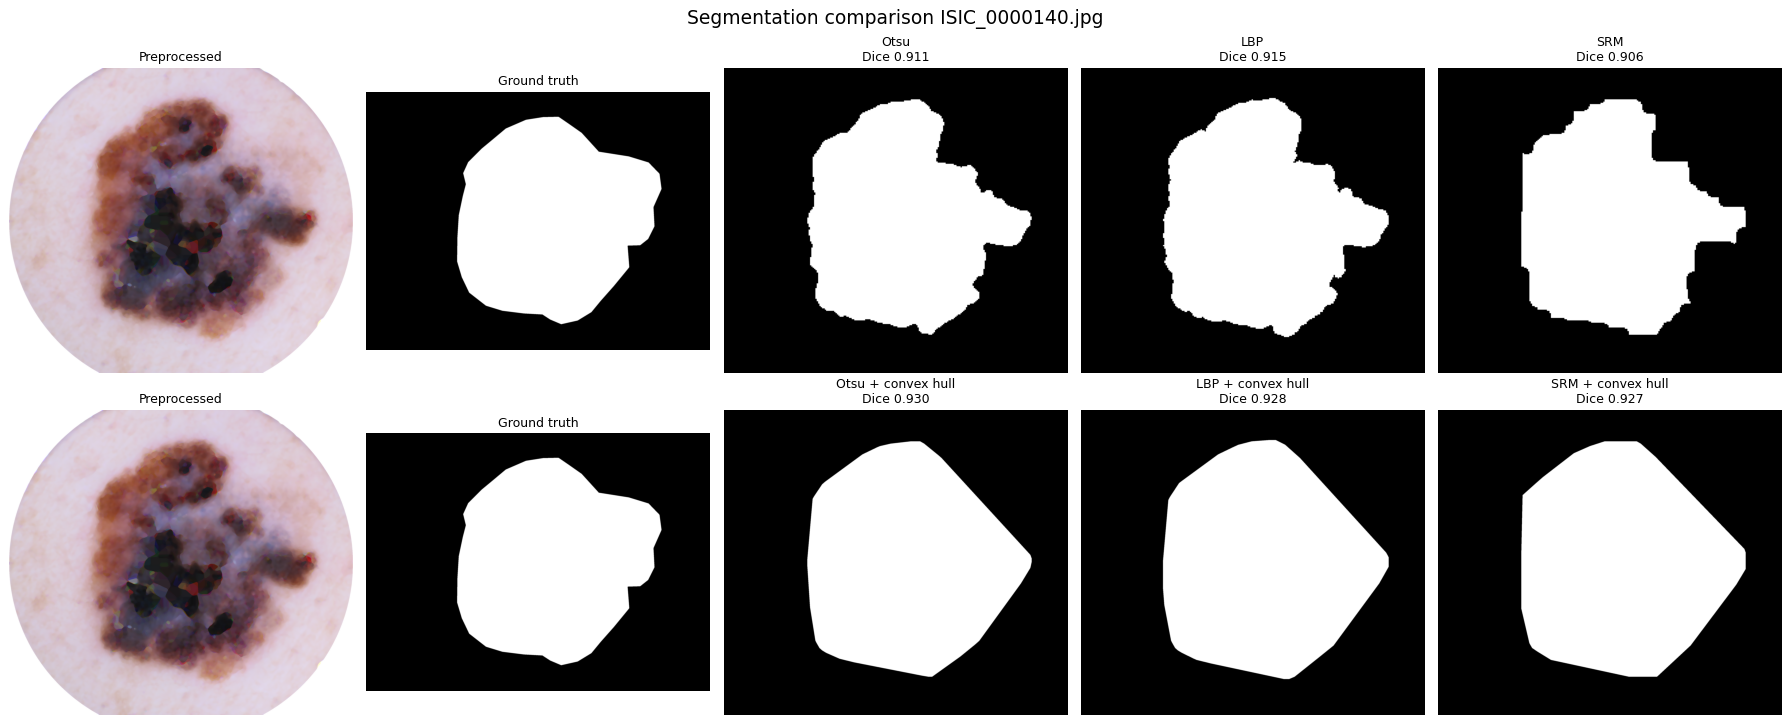

Otsu  Dice 0.911   with convex hull 0.930
LBP   Dice 0.915   with convex hull 0.928
SRM   Dice 0.906   with convex hull 0.927


In [8]:
outcome = run_all_methods(sample, keep_results=True)

figure = viz.plot_comparison(
    outcome.preprocessed,
    sample.ground_truth,
    outcome.masks,
    hulls=outcome.hulls,
    scores=outcome.scores,
    name=sample.name,
)
plt.show()

for method in METHODS:
    raw = outcome.scores[method]
    hull = outcome.scores[f"{method}_Hull"]
    print(f"{method:<5} Dice {raw:.3f}   with convex hull {hull:.3f}")

## 7. Results over the whole dataset

The table below is produced by `scripts/run_benchmark.py`, which runs the same
`run_all_methods` used above over all twenty images. Re-running it reproduces
these numbers exactly: every method is seeded.

In [9]:
results = pd.read_csv(ROOT / "reports" / "per_image_results.csv")
columns = [name for method in METHODS for name in (method, f"{method}_Hull")]

print("Mean Dice per category")
print(results.groupby("Category")[columns].mean().round(3).to_string())
print("\nMean Dice overall")
print(results[columns].mean().round(3).to_string())

Mean Dice per category
           Otsu  Otsu_Hull    LBP  LBP_Hull    SRM  SRM_Hull
Category                                                    
melanoma  0.823      0.877  0.850     0.896  0.782     0.845
nevus     0.866      0.917  0.893     0.872  0.852     0.887

Mean Dice overall
Otsu         0.844
Otsu_Hull    0.897
LBP          0.871
LBP_Hull     0.884
SRM          0.817
SRM_Hull     0.866


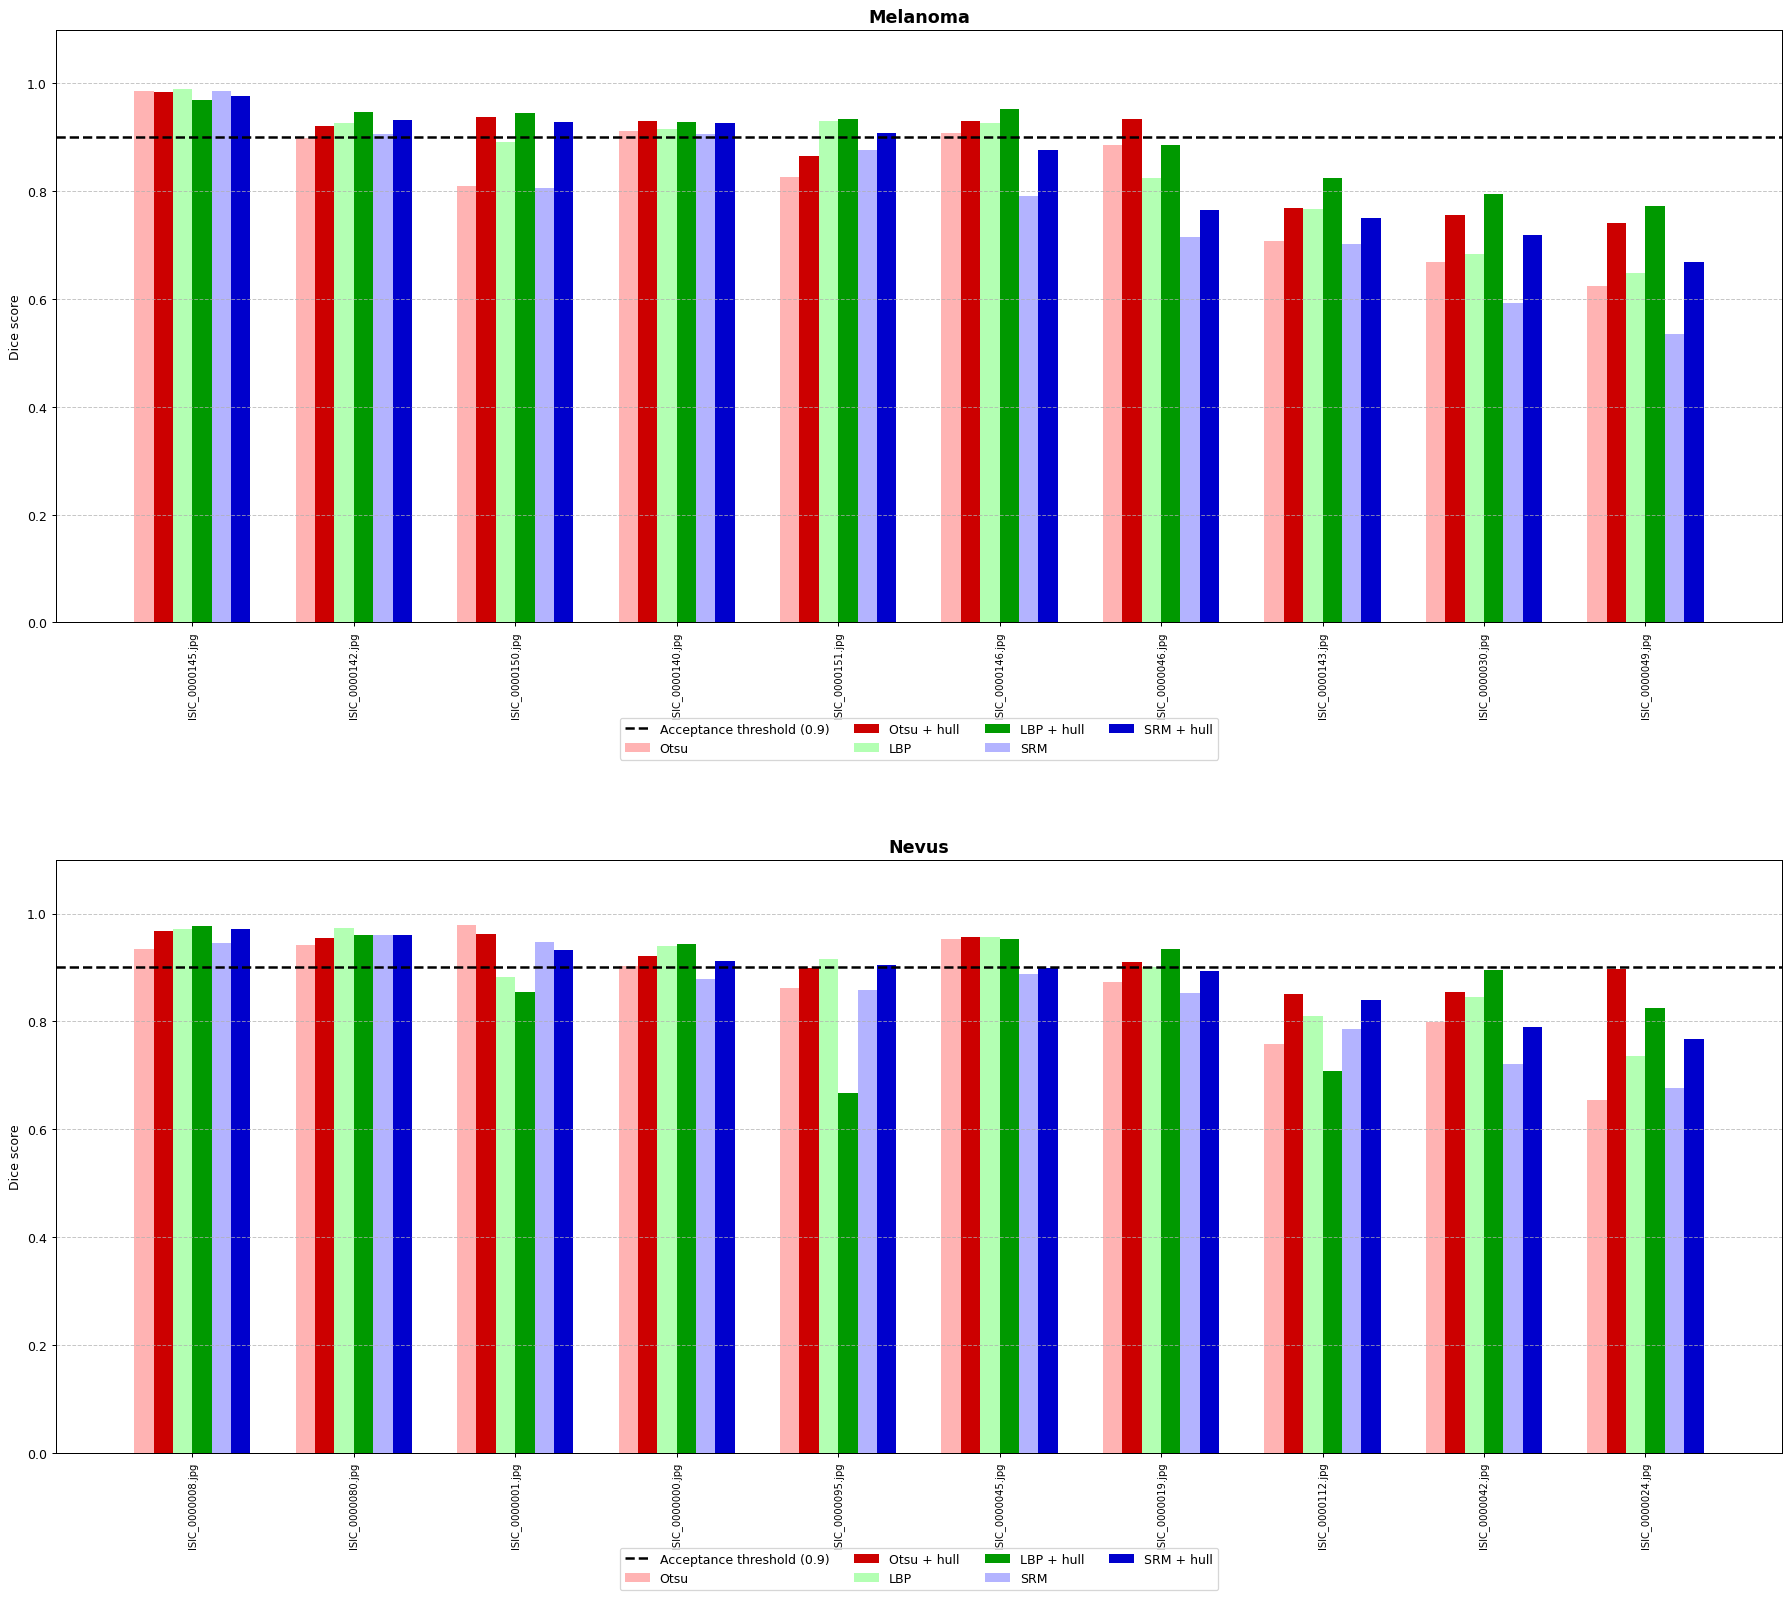

In [10]:
figure, axes = plt.subplots(2, 1, figsize=(20, 18))
viz.plot_dice_per_image(results[results.Category == "melanoma"], "Melanoma", axes[0])
viz.plot_dice_per_image(results[results.Category == "nevus"], "Nevus", axes[1])
figure.tight_layout()
figure.subplots_adjust(bottom=0.1, hspace=0.4)
plt.show()

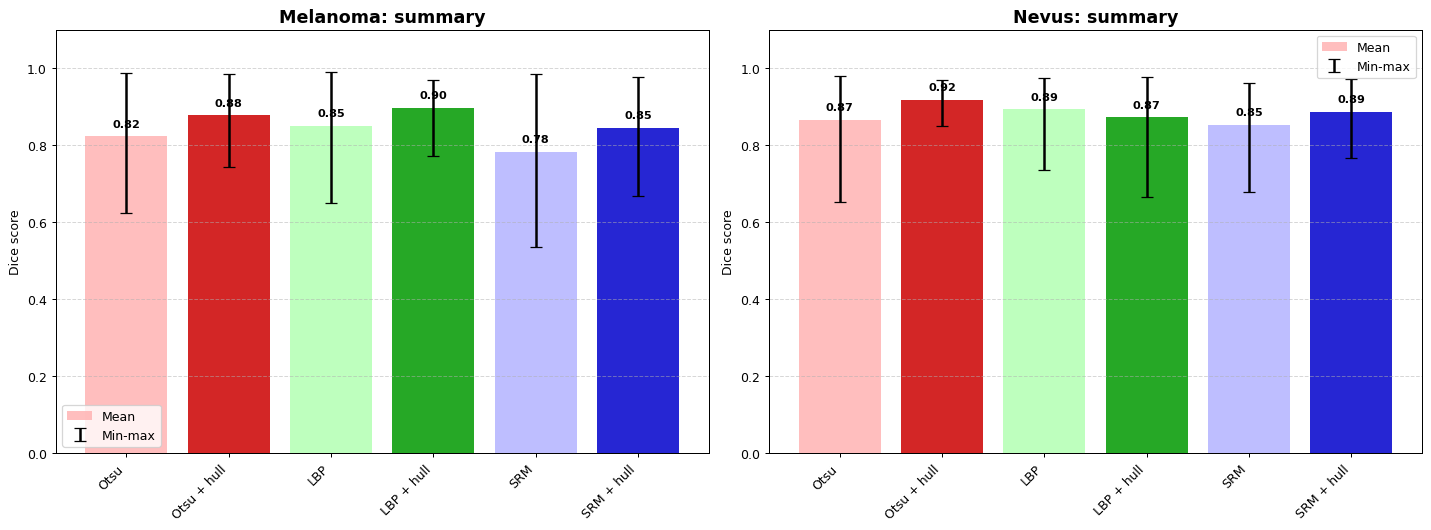

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(16, 6))
viz.plot_summary_stats(results[results.Category == "melanoma"], "Melanoma: summary", axes[0])
viz.plot_summary_stats(results[results.Category == "nevus"], "Nevus: summary", axes[1])
figure.tight_layout()
plt.show()

## 8. What the numbers say

**LBP Clustering gives the best raw masks** (mean Dice 0.871), ahead of Otsu
(0.844) and SRM (0.803). Its texture assumption holds well on the pigmented,
structurally busy lesions in this set.

**The convex hull helps, but not everywhere.** It lifts Otsu from 0.844 to
0.897 and SRM from 0.803 to 0.851, because both tend to fragment the lesion
and the hull glues the pieces back together. It barely helps LBP (0.871 to
0.884), whose masks are already connected, and on some nevi it actively hurts:
on ISIC_0000095 the LBP mask scores 0.915 and its hull only 0.666. Convexity is
an assumption about lesion shape, and nevi with a concave border violate it.

**Melanomas are harder than nevi** for all three methods, which is the
clinically expected direction: melanoma borders are irregular and poorly
defined by definition, and that is precisely what the ABCD rule looks for.

**The failures are informative.** ISIC_0000030 and ISIC_0000049 drag every
method down. Both are low-contrast lesions where no intensity or texture cue
cleanly separates lesion from skin. SRM collapses on ISIC_0000146 (0.440) where
its region scoring picks the wrong region. These are the cases a learned model
would handle better, and they mark the honest limit of the classical approach.